In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Correct path — file is already in project's data/raw
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\upi-shield\data\raw\paysim.csv.csv')

# Filter to fraud-relevant types only
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
print(f"Shape after filtering: {df.shape}")
print(df['isFraud'].value_counts())

Shape after filtering: (2770409, 11)
isFraud
0    2762196
1       8213
Name: count, dtype: int64


In [2]:
import os

# Search common locations
search_roots = [
    r'C:\Users\LENOVO\Downloads',
    r'C:\Users\LENOVO\Documents',
    r'C:\Users\LENOVO\Desktop',
]

for root in search_roots:
    for dirpath, dirnames, filenames in os.walk(root):
        for f in filenames:
            if 'PS_2017' in f or 'paysim' in f.lower():
                print(os.path.join(dirpath, f))

C:\Users\LENOVO\Downloads\upi-shield\data\raw\paysim.csv.csv


In [4]:
# 1. Time features
df['hour'] = df['step'] % 24
df['day'] = df['step'] // 24
df['is_weekend'] = df['day'] % 7

# 2. Transaction type encoding
df['type_encoded'] = (df['type'] == 'TRANSFER').astype(int)  # 1=TRANSFER, 0=CASH_OUT

# 3. Balance difference features
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# 4. Origin account drained to zero flag
df['orig_balance_zero'] = (df['newbalanceOrig'] == 0).astype(int)

# 5. Amount deviation from mean (per transaction type)
type_mean = df.groupby('type')['amount'].transform('mean')
df['amount_deviation'] = df['amount'] - type_mean

print("New features added:")
print(df[['hour','day','is_weekend','type_encoded',
          'balance_diff_orig','balance_diff_dest',
          'orig_balance_zero','amount_deviation']].head())

New features added:
    hour  day  is_weekend  type_encoded  balance_diff_orig  balance_diff_dest  \
2      1    0           0             1              181.0               0.00   
3      1    0           0             0              181.0          -21182.00   
15     1    0           0             0            15325.0           46430.44   
19     1    0           0             1              705.0          -22425.00   
24     1    0           0             1            10835.0         2712905.89   

    orig_balance_zero  amount_deviation  
2                   1    -910466.009645  
3                   1    -176092.964346  
15                  1      52859.975654  
19                  1    -695336.709645  
24                  1    -598961.119645  


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\LENOVO\\Downloads\\upi-shield\\reports\\figures\\day4_feature_validation.png'

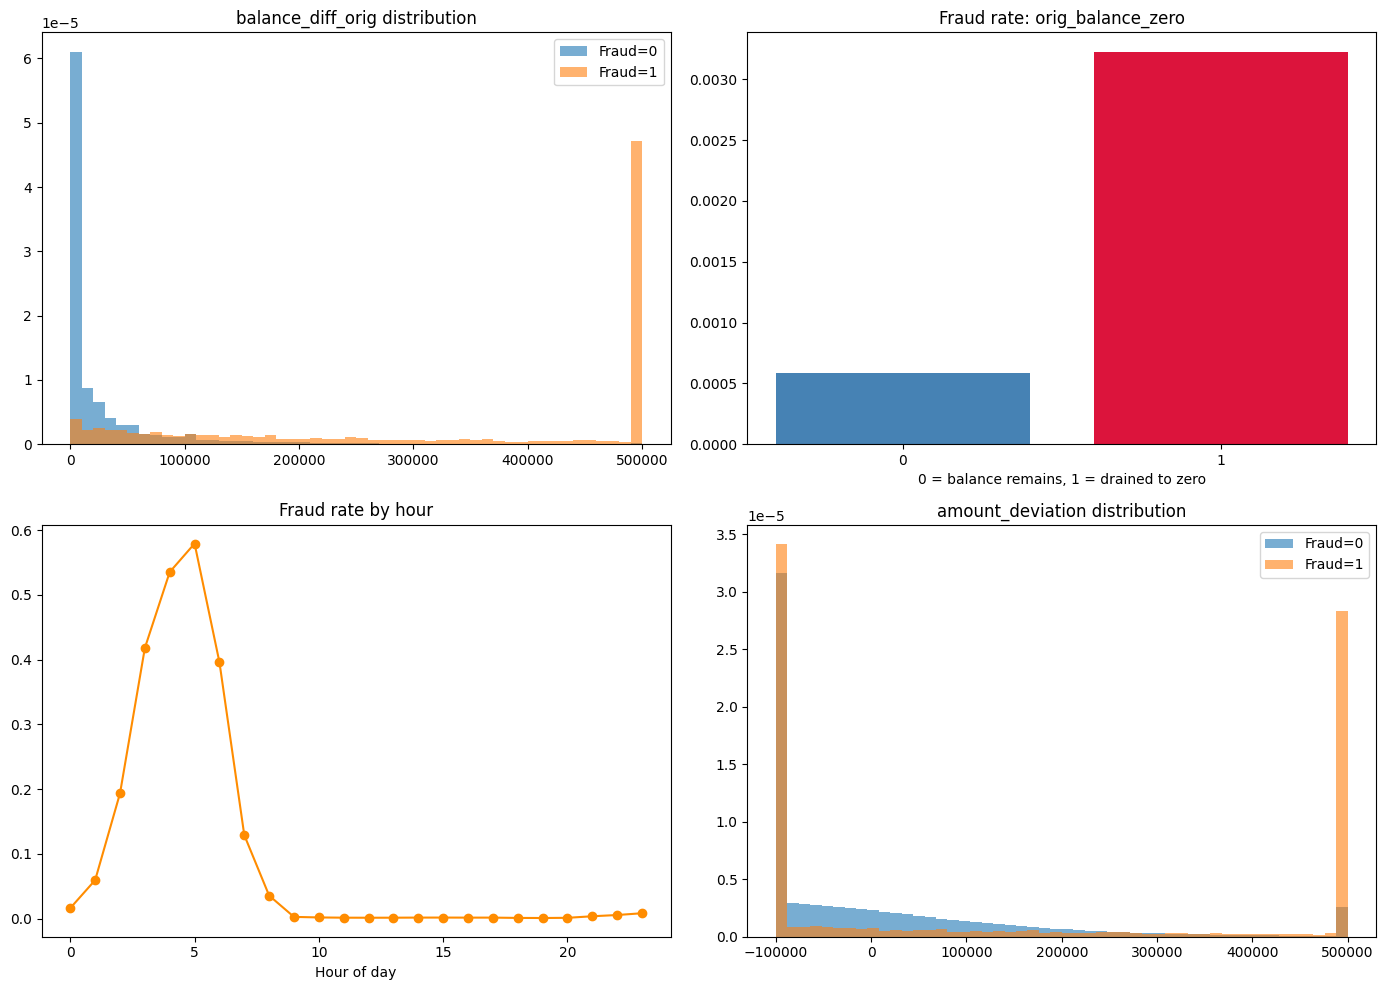

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# balance_diff_orig by fraud label
for label, grp in df.groupby('isFraud'):
    axes[0,0].hist(grp['balance_diff_orig'].clip(0, 500000), 
                   bins=50, alpha=0.6, label=f'Fraud={label}', density=True)
axes[0,0].set_title('balance_diff_orig distribution')
axes[0,0].legend()

# orig_balance_zero fraud rate
zero_fraud = df.groupby('orig_balance_zero')['isFraud'].mean()
axes[0,1].bar(zero_fraud.index.astype(str), zero_fraud.values, color=['steelblue','crimson'])
axes[0,1].set_title('Fraud rate: orig_balance_zero')
axes[0,1].set_xlabel('0 = balance remains, 1 = drained to zero')

# hour vs fraud rate
hour_fraud = df.groupby('hour')['isFraud'].mean()
axes[1,0].plot(hour_fraud.index, hour_fraud.values, marker='o', color='darkorange')
axes[1,0].set_title('Fraud rate by hour')
axes[1,0].set_xlabel('Hour of day')

# amount_deviation by fraud
for label, grp in df.groupby('isFraud'):
    axes[1,1].hist(grp['amount_deviation'].clip(-100000, 500000), 
                   bins=50, alpha=0.6, label=f'Fraud={label}', density=True)
axes[1,1].set_title('amount_deviation distribution')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day4_feature_validation.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import os
os.makedirs(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures', exist_ok=True)

plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day4_feature_validation.png', 
            dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [7]:
output_path = Path(r'C:\Users\LENOVO\Downloads\upi-shield\data\processed\featured_transactions.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Final shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved: C:\Users\LENOVO\Downloads\upi-shield\data\processed\featured_transactions.csv
Final shape: (2770409, 19)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour', 'day', 'is_weekend', 'type_encoded', 'balance_diff_orig', 'balance_diff_dest', 'orig_balance_zero', 'amount_deviation']


In [1]:
import subprocess
result = subprocess.run(
    ['python', r'C:\Users\LENOVO\Downloads\upi-shield\src\features.py'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

Loaded 2,770,409 transactions (8,213 fraud)
Saved: C:\Users\LENOVO\Downloads\upi-shield\data\processed\featured_transactions.csv — shape: (2770409, 19)


